# Classfication Track : BCI Motor Imagery

This notebook contains the classification pipeline for classifying 4 motor imagery tasks - left hand, right hand, tongue, feet using traditional machine learning techniques. We use the BCI Competition IV 2a dataset provided by Institute for Knowledge Discovery, Graz University of Technology. 

Unlike traditional ML pipelines, this project requires us to do signal processing + feature processing to develop a tabular dataset. The EEG data is time series in nature, and comes along with markers explaining when a particular task was imagined.

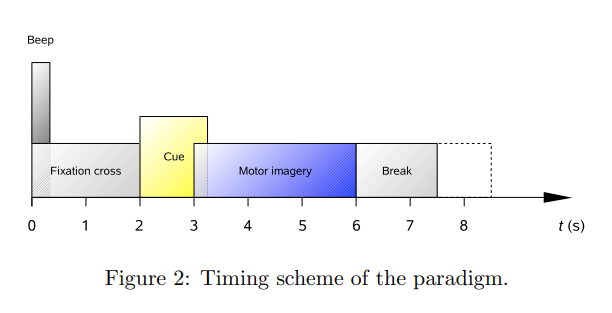

The above is the timing diagram of the experiment. Before the ML pipeline, we shall epoch each of these events, and apply processsing techniques like Common Spatial Pattern (CSP) to obtain numerical features, which will be fed to different classifiers in the pipeline.

In [15]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


mne.set_log_level('ERROR')

### Section A - Dataset and EDA

The competition provides two datasets for each subject. In our case there are 9 subject recording, however we shall limit to only using the first subject's data for this track. One dataset is supposed to be trained on fully, and should be tested on the evaluataion dataset.

##### A1 - Dataset Loading and Audit

In [16]:
raw_train_1 = mne.io.read_raw_gdf("../datasets/A01T.gdf")
raw_eval_1 = mne.io.read_raw_gdf("../datasets/A01E.gdf")

In [ ]:
eog_chs = raw_train_1.ch_names[-3:] 
raw_train_1.set_channel_types({ch: 'eog' for ch in eog_chs})

eog_chs_eval = raw_eval_1.ch_names[-3:]
raw_eval_1.set_channel_types({ch: 'eog' for ch in eog_chs_eval})


In [23]:
raw_train_1

<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~24 KiB, data not loaded>

In [22]:
raw_eval_1

<RawGDF | A01E.gdf, 25 x 687000 (2748.0 s), ~24 KiB, data not loaded>

In [27]:
events, event_id = mne.events_from_annotations(raw_train_1, verbose=False)

marker_label = {
    1: "Rejected Trial",
    2: "Eye movments",
    3: "Idling EEG (eyes open)",
    4: "Idling EEG (eyes closed)",
    5: "Start of a new run",
    6: "Start of a trial",
    7: "left_hand",
    8: "right_hand",
    9: "feet",
    10: "tongue",
}

mi_event_id = {marker_label[v]: v for k, v in event_id.items()
               if marker_label[v] in ['left_hand', 'right_hand', 'feet', 'tongue']}

mi_epochs = mne.Epochs(raw_train_1, events, event_id=mi_event_id,
                        tmin=-0.5, tmax=5.25, baseline=None, preload=True)

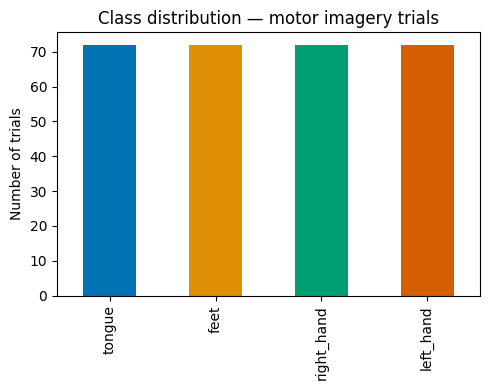

In [28]:
class_counts = pd.Series(mi_epochs.events[:, -1]).map(
    {v: k for k, v in mi_event_id.items()}
).value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind='bar', ax=ax, color=sns.color_palette('colorblind'))
ax.set_ylabel("Number of trials")
ax.set_title("Class distribution — motor imagery trials")
plt.tight_layout()
plt.show()